# CIF — Cumulative Incidence Functions with Interaction Specifications

## What is a CIF?

A **Cumulative Incidence Function (CIF)** answers:

> Given a conflict that starts at quarter 0, what is the probability it will have
> exited via a *specific route* by quarter T?

In this competing-risks framework, three mutually exclusive exits compete:

| Label | Exit route |
|---|---|
| **S** | Signing — the conflict reaches a first peace agreement |
| **V** | Victory — one party achieves outright military victory |
| **F** | Fade — the conflict ends through a sustained low-activity fade-out |

`CIF_S(T)` is the *marginal* probability of signing by quarter T, properly
accounting for the fact that a conflict that ended via victory or fade at some
earlier point can **never** sign afterwards.

This is the key difference from a standard Kaplan-Meier survival estimate, which
treats competing exits as independent censoring. That assumption is violated here:
whether a conflict ends by victory vs. signing is not random — it is correlated with
the very covariates we study. Using cause-specific KM curves would overestimate
signing probabilities by ignoring that some conflicts are permanently removed by
a competing exit before they can sign.

**Reading a CIF plot.** At any horizon T, compare two profiles:
- `CIF_S(T | HighIA = 1)` vs. `CIF_S(T | HighIA = 0)`
- The vertical gap is the estimated difference in cumulative signing probability
  attributable to information asymmetry.
- All three CIF curves (S, V, F) for a given profile sum to at most 1; the remainder
  is the probability of still being in conflict at T.

---

## Why interaction specifications (M3 / M5)?

The additive specifications M2 and M4 impose a **constant** proportional effect
of HighIA (or HighEF) on the sub-hazard of signing across all conflict ages.
This implies that the CIF curves for the two groups accumulate at a proportionally
steady rate — the gap builds up uniformly over the conflict lifecycle.

The interaction specifications **allow the group effect to change with age**:

| Spec | Formula | What it allows |
|---|---|---|
| M3 | `log(age) + HighIA + log(age) × HighIA` | IA effect varies with conflict age |
| M5 | `log(age) + HighEF + log(age) × HighEF` | EF effect varies with conflict age |

Interpreting the interaction coefficient `β₃ = β(log_age × HighIA)`:

- **β₃ < 0**: the IA advantage in reaching agreements *weakens* as the conflict matures.
  Theoretically: fighting resolves information asymmetries early; once both sides know
  each other's strength, IA no longer distinguishes who signs.
  → CIF curves start far apart and converge over time.

- **β₃ > 0**: the IA advantage *grows* with conflict age.
  → CIF curves start close and diverge.

The M3/M5 CIF plots are more informative than M2/M4 because they reveal *when* in the
conflict lifecycle the group difference in signing probability is largest.

---

*Notebook runs three baselines (log-age, age-bins, age-bins + decade controls),
each using M3 for the IA channel and M5 for the EF channel.*


In [10]:
import sys
import os
sys.path.insert(0, 'functions')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from cloglog_hazard import fit_mnlogit
from compute_cif   import compute_cif
utils_path = os.path.abspath(
    os.path.join(os.getcwd(), '..', '2_data_analysis', 'utils')
)
sys.path.append(utils_path)
import plot_style
os.makedirs('results', exist_ok=True)


In [11]:
# ── Load data and replicate setup from 2_competing_risks_analysis.ipynb ───────

spell_q = pd.read_csv('../../data/output/conflict_level/spell_q.csv')
spell_q['yq']     = pd.PeriodIndex(spell_q['yq'], freq='Q')
spell_q['year_q'] = spell_q['yq'].dt.year

# Outcome variables
spell_q['_last_q'] = (
    spell_q.groupby('conflict_id')['conflict_age_q'].transform('max')
    == spell_q['conflict_age_q']
)
spell_q['y_multi'] = 0
spell_q.loc[spell_q['is_first_agreement'] == 1,                             'y_multi'] = 1
spell_q.loc[spell_q['_last_q'] & (spell_q['cause_label'] == 'not at risk'), 'y_multi'] = 2
spell_q.loc[spell_q['_last_q'] & (spell_q['cause_label'] == 'fade'),        'y_multi'] = 3

# Derived covariates
spell_q['log_age_x_ia'] = spell_q['log_conflict_age_q'] * spell_q['high_ia_bin']
spell_q['log_age_x_ef'] = spell_q['log_conflict_age_q'] * spell_q['high_fe_etfra_bin']

spell_q['d_2000s'] = (spell_q['year_q'] >= 2000).astype(int)
spell_q['d_2010s'] = (spell_q['year_q'] >= 2010).astype(int)
spell_q['d_2020s'] = (spell_q['year_q'] >= 2020).astype(int)

_bins = [0, 4, 8, 16, 32, np.inf]
spell_q['age_bin'] = pd.cut(spell_q['conflict_age_q'], bins=_bins,
                              labels=['1-4Q','5-8Q','9-16Q','17-32Q','33+Q'], right=True)
BIN_COLS = {'5-8Q':'abin_5_8Q','9-16Q':'abin_9_16Q',
            '17-32Q':'abin_17_32Q','33+Q':'abin_33pQ'}
age_bin_cols = list(BIN_COLS.values())
for _lbl, _col in BIN_COLS.items():
    spell_q[_col] = (spell_q['age_bin'] == _lbl).astype(float)

bin_x_ia_cols, bin_x_ef_cols = [], []
for _b in age_bin_cols:
    spell_q[f'{_b}_x_ia'] = spell_q[_b] * spell_q['high_ia_bin']
    spell_q[f'{_b}_x_ef'] = spell_q[_b] * spell_q['high_fe_etfra_bin']
    bin_x_ia_cols.append(f'{_b}_x_ia')
    bin_x_ef_cols.append(f'{_b}_x_ef')

DEC_COLS = ['d_2000s', 'd_2010s', 'd_2020s']

# Interaction-spec covariate lists (M3 and M5 for each baseline)
M3_LOG  = ['log_conflict_age_q', 'high_ia_bin', 'log_age_x_ia']
M5_LOG  = ['log_conflict_age_q', 'high_fe_etfra_bin', 'log_age_x_ef']

M3_BINS = age_bin_cols + ['high_ia_bin'] + bin_x_ia_cols
M5_BINS = age_bin_cols + ['high_fe_etfra_bin'] + bin_x_ef_cols

M3_DEC  = age_bin_cols + DEC_COLS + ['high_ia_bin'] + bin_x_ia_cols
M5_DEC  = age_bin_cols + DEC_COLS + ['high_fe_etfra_bin'] + bin_x_ef_cols

# Evaluation grid and horizon points
AGE_RANGE = np.arange(1, 41)
HORIZONS  = [4, 8, 16, 32, 40]

print(f"spell_q: {len(spell_q):,} conflict-quarters  |  {spell_q['conflict_id'].nunique()} conflicts")
print(f"y_multi distribution: { {k: (spell_q['y_multi']==k).sum() for k in range(4)} }")


spell_q: 6,188 conflict-quarters  |  201 conflicts
y_multi distribution: {0: np.int64(6026), 1: np.int64(98), 2: np.int64(33), 3: np.int64(31)}


In [12]:
# ── Plot and horizon-table helpers ────────────────────────────────────────────

def _print_horizons(cif1, cif0, lbl1, lbl0, col='CIF_S'):
    """Print CIF values at fixed horizons for two profiles."""
    print(f"  {'Q':<6} {lbl1:>12} {lbl0:>12} {'diff':>10}")
    print(f"  {'-'*44}")
    for h in HORIZONS:
        row1 = cif1.loc[cif1['age_q'] == h, col]
        row0 = cif0.loc[cif0['age_q'] == h, col]
        if row1.empty or row0.empty:
            continue
        v1, v0 = row1.iloc[0], row0.iloc[0]
        print(f"  {h:<6} {v1:>12.3f} {v0:>12.3f} {v1-v0:>+10.3f}")
    print()


def _style_ax(ax):
    """Black bottom+left spines only; tick labels in black; no grid."""
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.8)
    ax.tick_params(axis='both', colors='black', labelsize=10)
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')


def _plot_cif(cif_ia1, cif_ia0, cif_ef1, cif_ef0, title_suffix, save_path):
    """
    Two-panel CIF plot.
    Left:  signing CIF by HighIA group (from M3).
    Right: signing CIF by HighEF group (from M5).
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, (c1, c0, grp_lbl, spec_lbl) in zip(axes, [
        (cif_ia1, cif_ia0, 'HighIA', 'M3'),
        (cif_ef1, cif_ef0, 'HighEF', 'M5'),
    ]):
        ax.plot(c1['age_q'], c1['CIF_S'], lw=2, label=f'{grp_lbl}=1 (signing)')
        ax.plot(c0['age_q'], c0['CIF_S'], lw=2, linestyle='--', label=f'{grp_lbl}=0 (signing)')
        ax.plot(c1['age_q'], c1['CIF_V'], lw=1.2, alpha=0.5, label=f'{grp_lbl}=1 (victory)')
        ax.plot(c1['age_q'], c1['CIF_F'], lw=1.2, alpha=0.5, linestyle=':', label=f'{grp_lbl}=1 (fade)')
        ax.fill_between(c1['age_q'], c1['CIF_S'], c0['CIF_S'], alpha=0.12)
        ax.set_xlabel('Conflict age (quarters)', fontsize=10)
        ax.set_ylabel('Cumulative incidence', fontsize=10)
        ax.set_title(f'{grp_lbl} channel ({spec_lbl}) — {title_suffix}', fontsize=14)
        ax.legend(fontsize=10)
        _style_ax(ax)

    plt.suptitle(f'Cumulative Incidence Functions — {title_suffix}', y=1.02, fontsize=15)
    plt.tight_layout()
    os.makedirs('results', exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {save_path}")


---
## 1.  Log-age baseline — M3 (HighIA×age) and M5 (HighEF×age)

Covariate lists:
- **M3**: `log(age)  +  HighIA  +  log(age)×HighIA`
- **M5**: `log(age)  +  HighEF  +  log(age)×HighEF`

The interaction term means the sub-hazard ratio for the group variable changes
with conflict age. The CIF curves can therefore converge or diverge over time,
revealing *when* in the conflict lifecycle the group difference in signing
probability is largest.


In [13]:
# ── 1.  Fit MNLogit — log-age baseline (M3 and M5) ──────────────────────────

print("Fitting MNLogit — log-age: M3 (HighIA×age)")
mn_ia_log = fit_mnlogit(M3_LOG, spell_q)

print("Fitting MNLogit — log-age: M5 (HighEF×age)")
mn_ef_log = fit_mnlogit(M5_LOG, spell_q)

print("Done.")


Fitting MNLogit — log-age: M3 (HighIA×age)
Fitting MNLogit — log-age: M5 (HighEF×age)
Done.


CIF_S at key horizons — HighIA channel (M3, log-age):
  Q          HighIA=1     HighIA=0       diff
  --------------------------------------------
  4             0.168        0.103     +0.065
  8             0.241        0.168     +0.073
  16            0.317        0.257     +0.060
  32            0.388        0.366     +0.023
  40            0.409        0.403     +0.005

CIF_S at key horizons — HighEF channel (M5, log-age):
  Q          HighEF=1     HighEF=0       diff
  --------------------------------------------
  4             0.114        0.157     -0.043
  8             0.183        0.224     -0.041
  16            0.274        0.294     -0.020
  32            0.383        0.359     +0.024
  40            0.419        0.377     +0.042



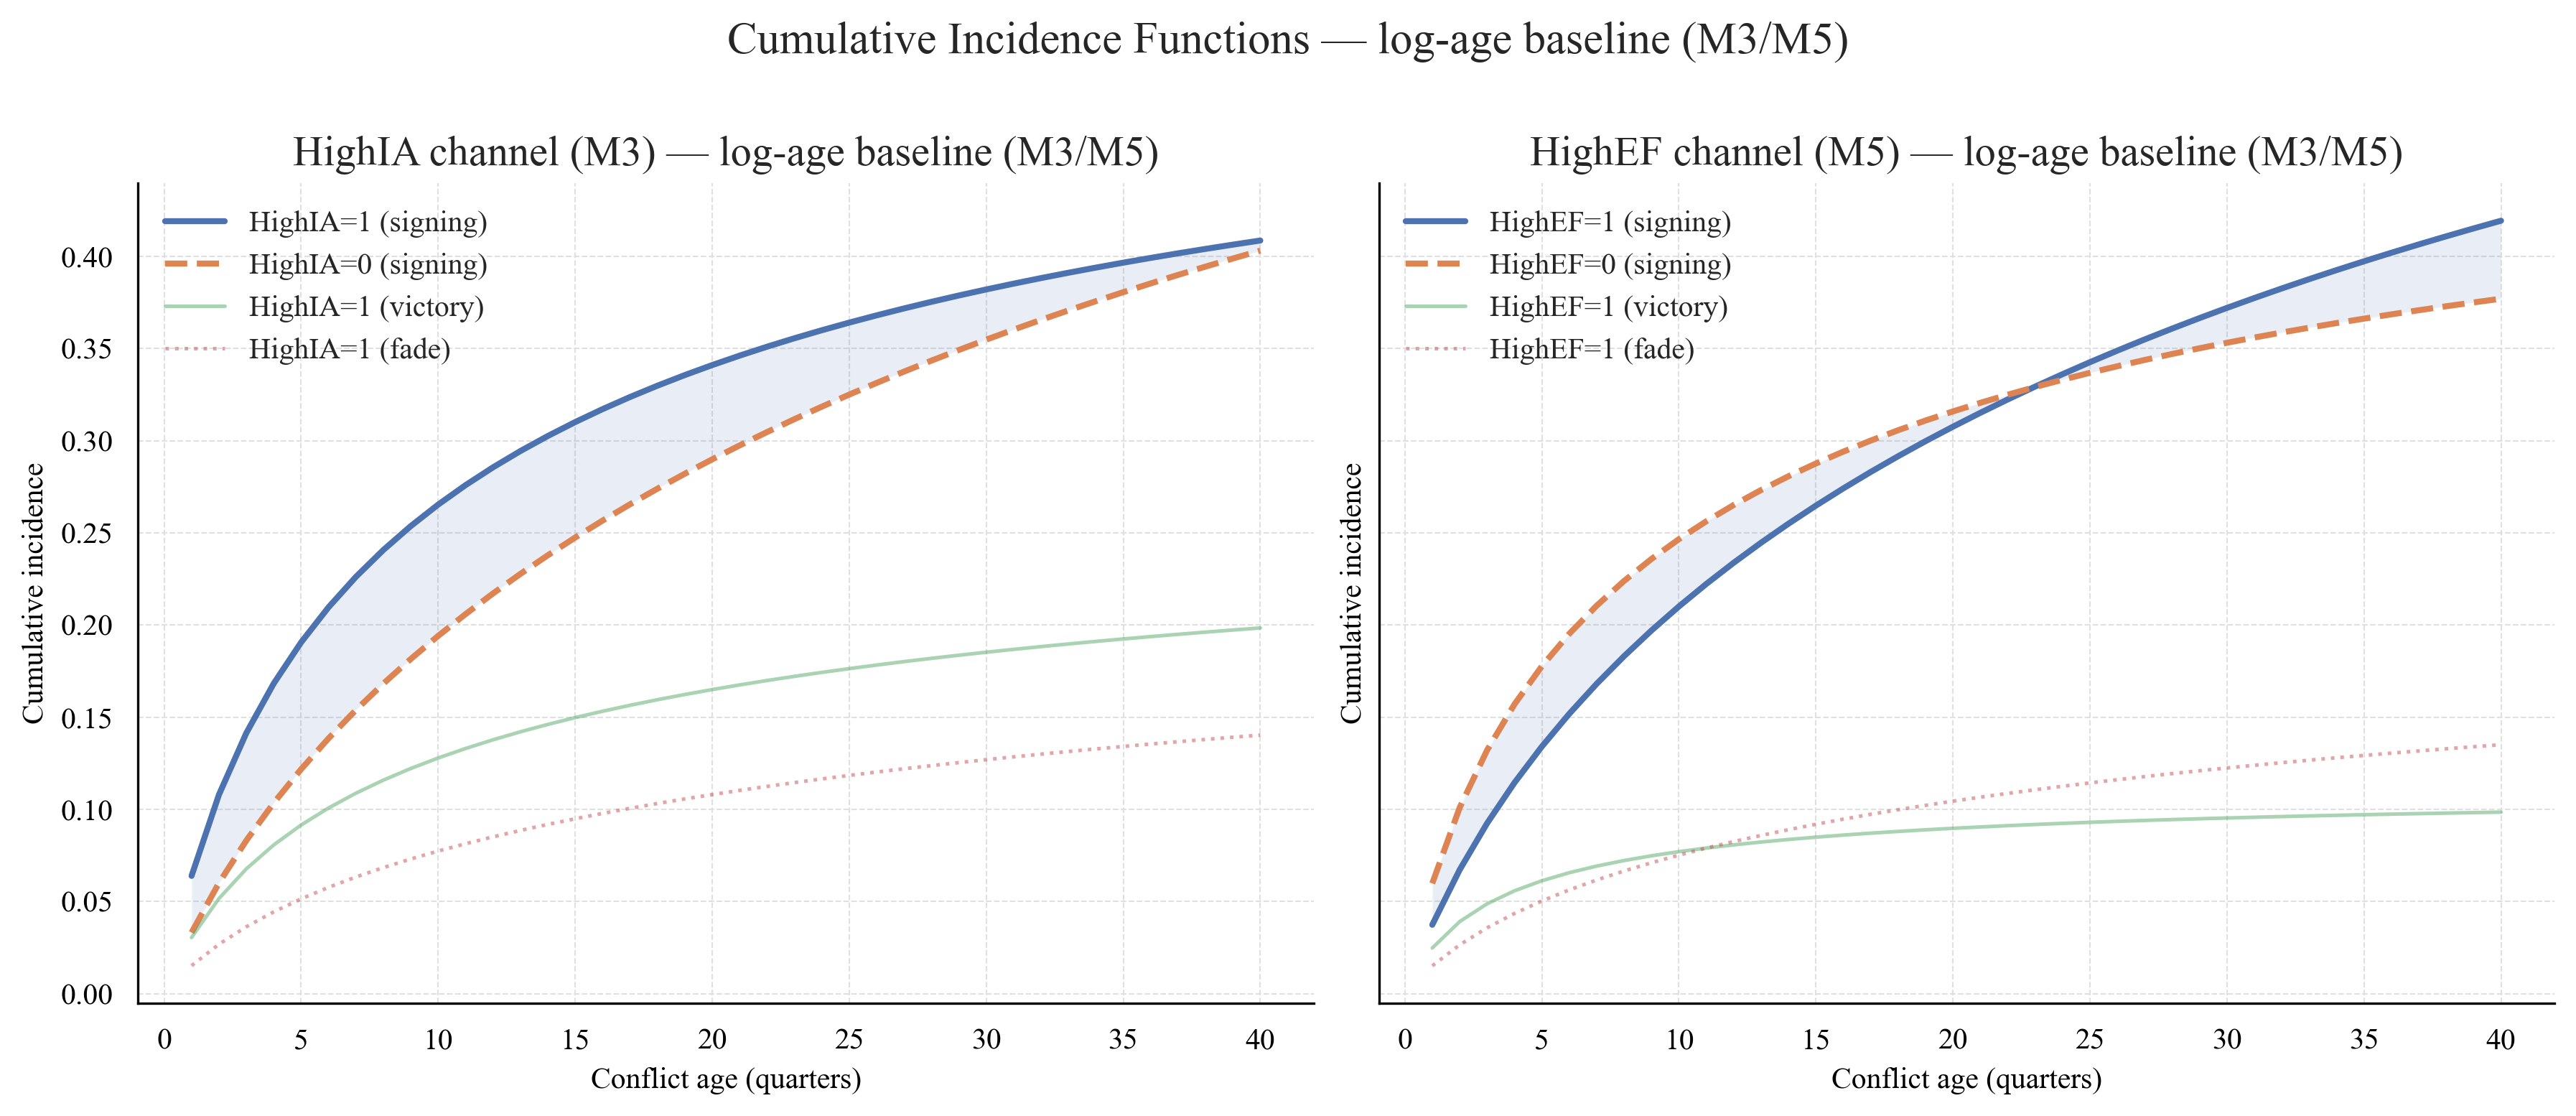

  Saved: results/cif_interaction_log.png


In [14]:
# ── 1.  Compute and plot CIF — log-age baseline ───────────────────────────────

cif_ia1_log = compute_cif(mn_ia_log, M3_LOG, AGE_RANGE, high_ia_bin=1)
cif_ia0_log = compute_cif(mn_ia_log, M3_LOG, AGE_RANGE, high_ia_bin=0)
cif_ef1_log = compute_cif(mn_ef_log, M5_LOG, AGE_RANGE, high_fe_etfra_bin=1)
cif_ef0_log = compute_cif(mn_ef_log, M5_LOG, AGE_RANGE, high_fe_etfra_bin=0)

print("CIF_S at key horizons — HighIA channel (M3, log-age):")
_print_horizons(cif_ia1_log, cif_ia0_log, 'HighIA=1', 'HighIA=0', 'CIF_S')

print("CIF_S at key horizons — HighEF channel (M5, log-age):")
_print_horizons(cif_ef1_log, cif_ef0_log, 'HighEF=1', 'HighEF=0', 'CIF_S')

_plot_cif(cif_ia1_log, cif_ia0_log, cif_ef1_log, cif_ef0_log,
          title_suffix='log-age baseline (M3/M5)',
          save_path='results/cif_interaction_log.png')


---
## 2.  Age-bin baseline — M3b (HighIA×bins) and M5b (HighEF×bins)

Covariate lists:
- **M3b**: age-bin dummies  +  `HighIA`  +  `bin×HighIA` for each bin
- **M5b**: age-bin dummies  +  `HighEF`  +  `bin×HighEF` for each bin

The interaction here is between group membership and each age bin separately,
rather than a smooth log-age interaction. This is more flexible but uses more
parameters.


In [15]:
# ── 2.  Fit MNLogit — age-bin baseline (M3b and M5b) ─────────────────────────

print("Fitting MNLogit — age-bin: M3b (HighIA×bins)")
mn_ia_bins = fit_mnlogit(M3_BINS, spell_q)

print("Fitting MNLogit — age-bin: M5b (HighEF×bins)")
mn_ef_bins = fit_mnlogit(M5_BINS, spell_q)

print("Done.")


Fitting MNLogit — age-bin: M3b (HighIA×bins)
Fitting MNLogit — age-bin: M5b (HighEF×bins)
Done.


CIF_S at key horizons — HighIA channel (M3b, age-bin):
  Q          HighIA=1     HighIA=0       diff
  --------------------------------------------
  4             0.147        0.106     +0.041
  8             0.239        0.189     +0.050
  16            0.333        0.264     +0.068
  32            0.413        0.370     +0.043
  40            0.424        0.400     +0.024

CIF_S at key horizons — HighEF channel (M5b, age-bin):
  Q          HighEF=1     HighEF=0       diff
  --------------------------------------------
  4             0.129        0.100     +0.030
  8             0.195        0.233     -0.038
  16            0.285        0.301     -0.016
  32            0.393        0.370     +0.023
  40            0.421        0.382     +0.039



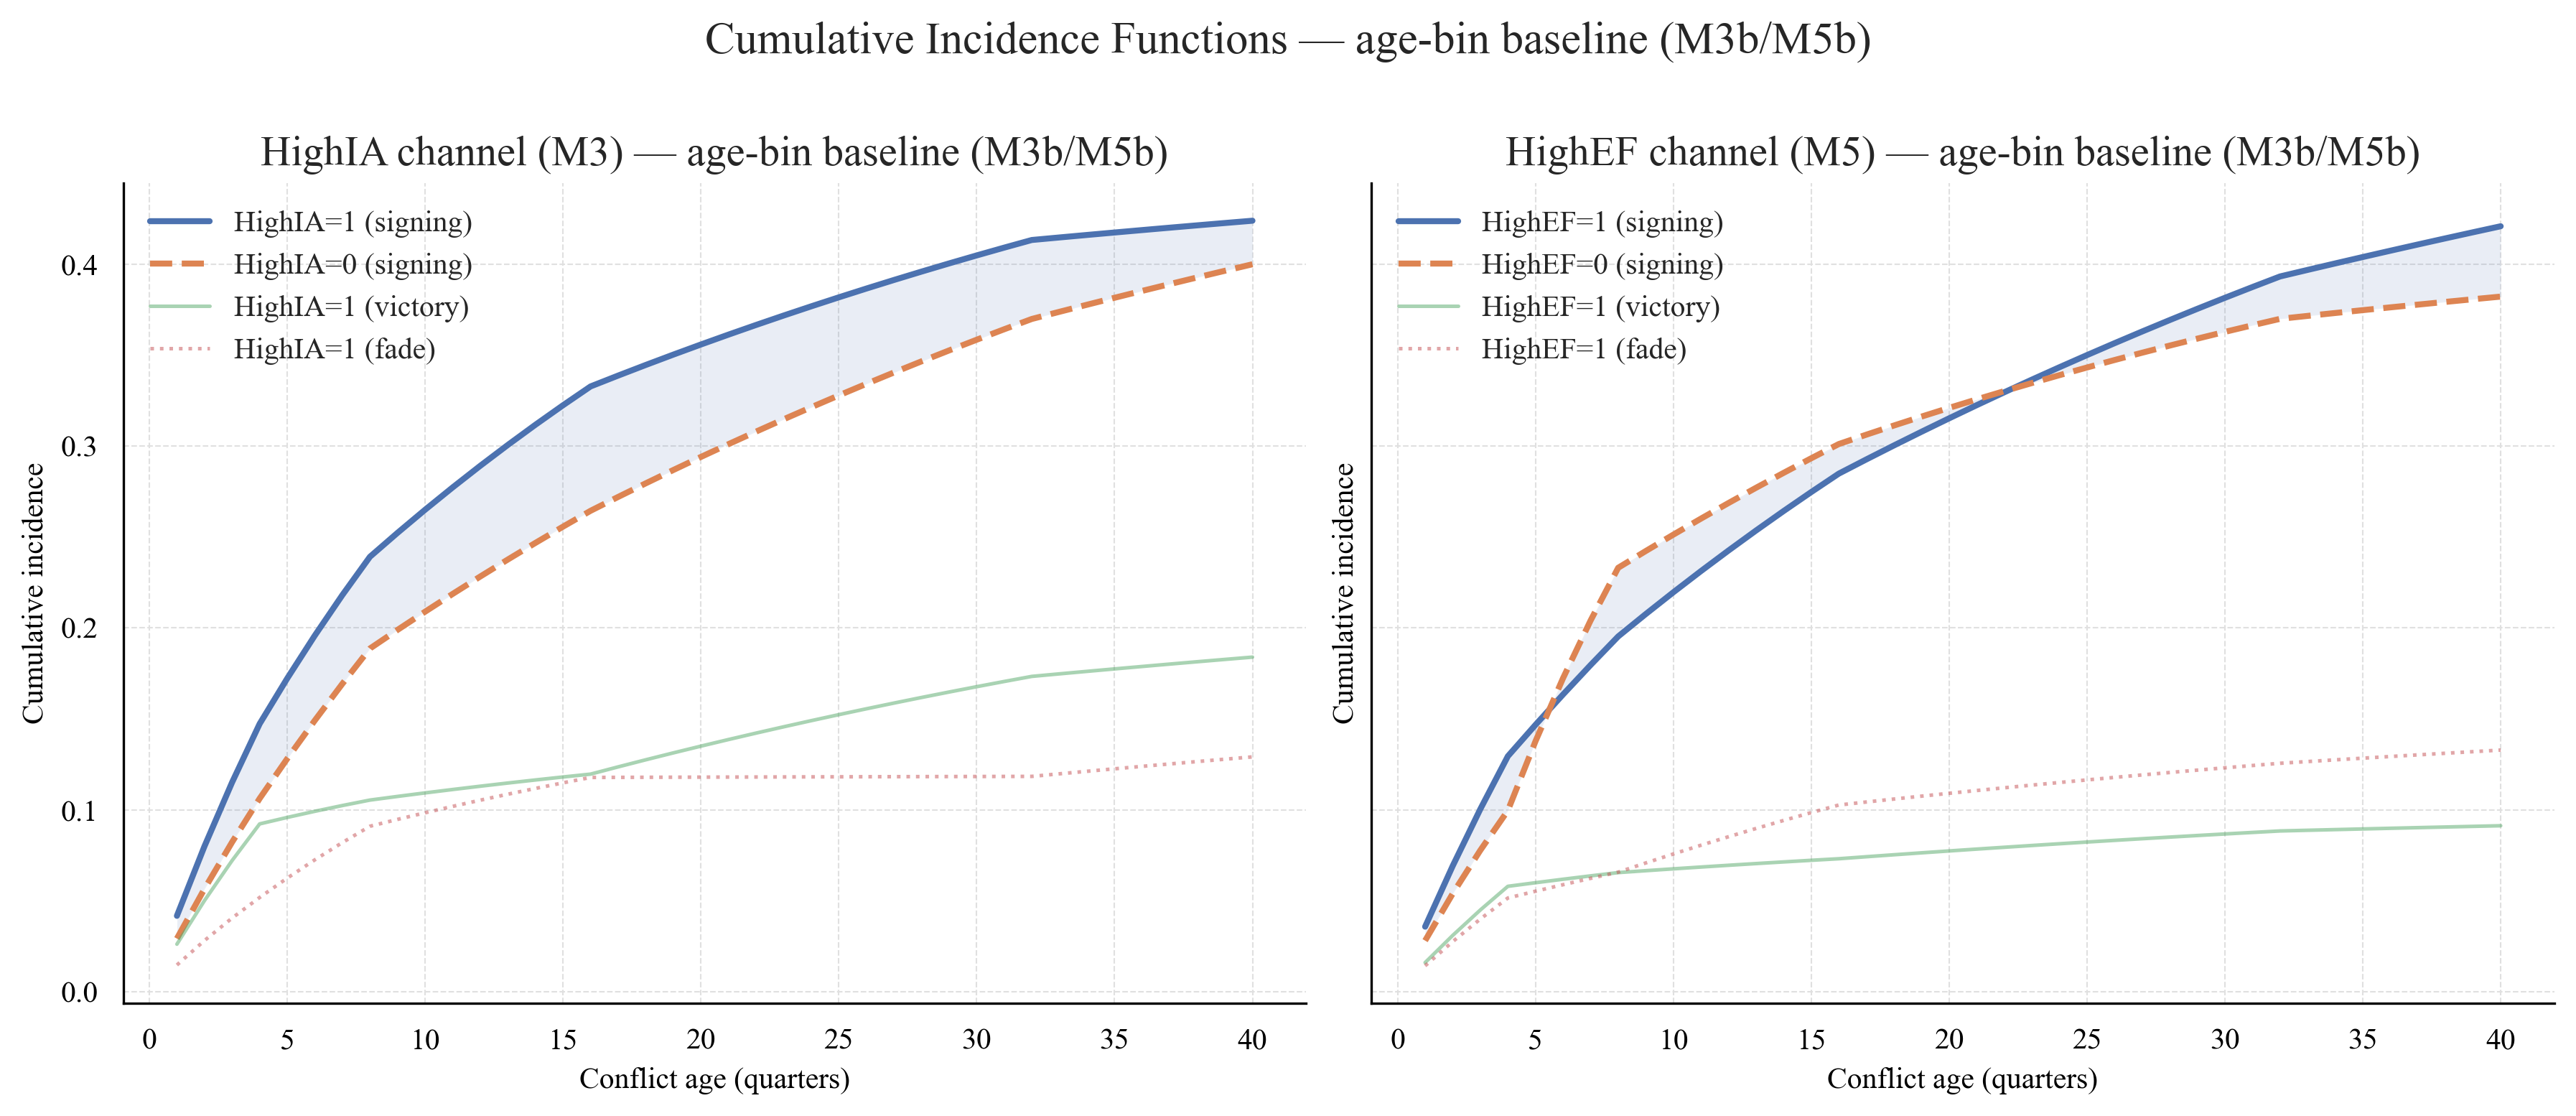

  Saved: results/cif_interaction_bins.png


In [16]:
# ── 2.  Compute and plot CIF — age-bin baseline ───────────────────────────────

cif_ia1_bins = compute_cif(mn_ia_bins, M3_BINS, AGE_RANGE, high_ia_bin=1)
cif_ia0_bins = compute_cif(mn_ia_bins, M3_BINS, AGE_RANGE, high_ia_bin=0)
cif_ef1_bins = compute_cif(mn_ef_bins, M5_BINS, AGE_RANGE, high_fe_etfra_bin=1)
cif_ef0_bins = compute_cif(mn_ef_bins, M5_BINS, AGE_RANGE, high_fe_etfra_bin=0)

print("CIF_S at key horizons — HighIA channel (M3b, age-bin):")
_print_horizons(cif_ia1_bins, cif_ia0_bins, 'HighIA=1', 'HighIA=0', 'CIF_S')

print("CIF_S at key horizons — HighEF channel (M5b, age-bin):")
_print_horizons(cif_ef1_bins, cif_ef0_bins, 'HighEF=1', 'HighEF=0', 'CIF_S')

_plot_cif(cif_ia1_bins, cif_ia0_bins, cif_ef1_bins, cif_ef0_bins,
          title_suffix='age-bin baseline (M3b/M5b)',
          save_path='results/cif_interaction_bins.png')


---
## 3.  Age-bin + decade controls — M3c (HighIA×bins) and M5c (HighEF×bins)

Same as Section 2 with decade dummies added: `d_2000s`, `d_2010s`, `d_2020s`
(reference = conflicts starting before 2000).

CIF evaluation profile: **2010s** (`d_2000s=1, d_2010s=1, d_2020s=0`).
This means the CIF is computed for a typical conflict starting in the 2010s.


In [17]:
# ── 3.  Fit MNLogit — age-bin + decade controls (M3c and M5c) ────────────────

print("Fitting MNLogit — age-bin + decades: M3c (HighIA×bins)")
mn_ia_dec = fit_mnlogit(M3_DEC, spell_q)

print("Fitting MNLogit — age-bin + decades: M5c (HighEF×bins)")
mn_ef_dec = fit_mnlogit(M5_DEC, spell_q)

print("Done.")


Fitting MNLogit — age-bin + decades: M3c (HighIA×bins)
Fitting MNLogit — age-bin + decades: M5c (HighEF×bins)
Done.


CIF_S at key horizons — HighIA channel (M3c, age-bin + dec, 2010s profile):
  Q          HighIA=1     HighIA=0       diff
  --------------------------------------------
  4             0.092        0.062     +0.030
  8             0.149        0.112     +0.037
  16            0.209        0.160     +0.049
  32            0.270        0.235     +0.035
  40            0.282        0.269     +0.013

CIF_S at key horizons — HighEF channel (M5c, age-bin + dec, 2010s profile):
  Q          HighEF=1     HighEF=0       diff
  --------------------------------------------
  4             0.081        0.055     +0.026
  8             0.122        0.131     -0.009
  16            0.178        0.173     +0.006
  32            0.255        0.224     +0.030
  40            0.284        0.239     +0.045



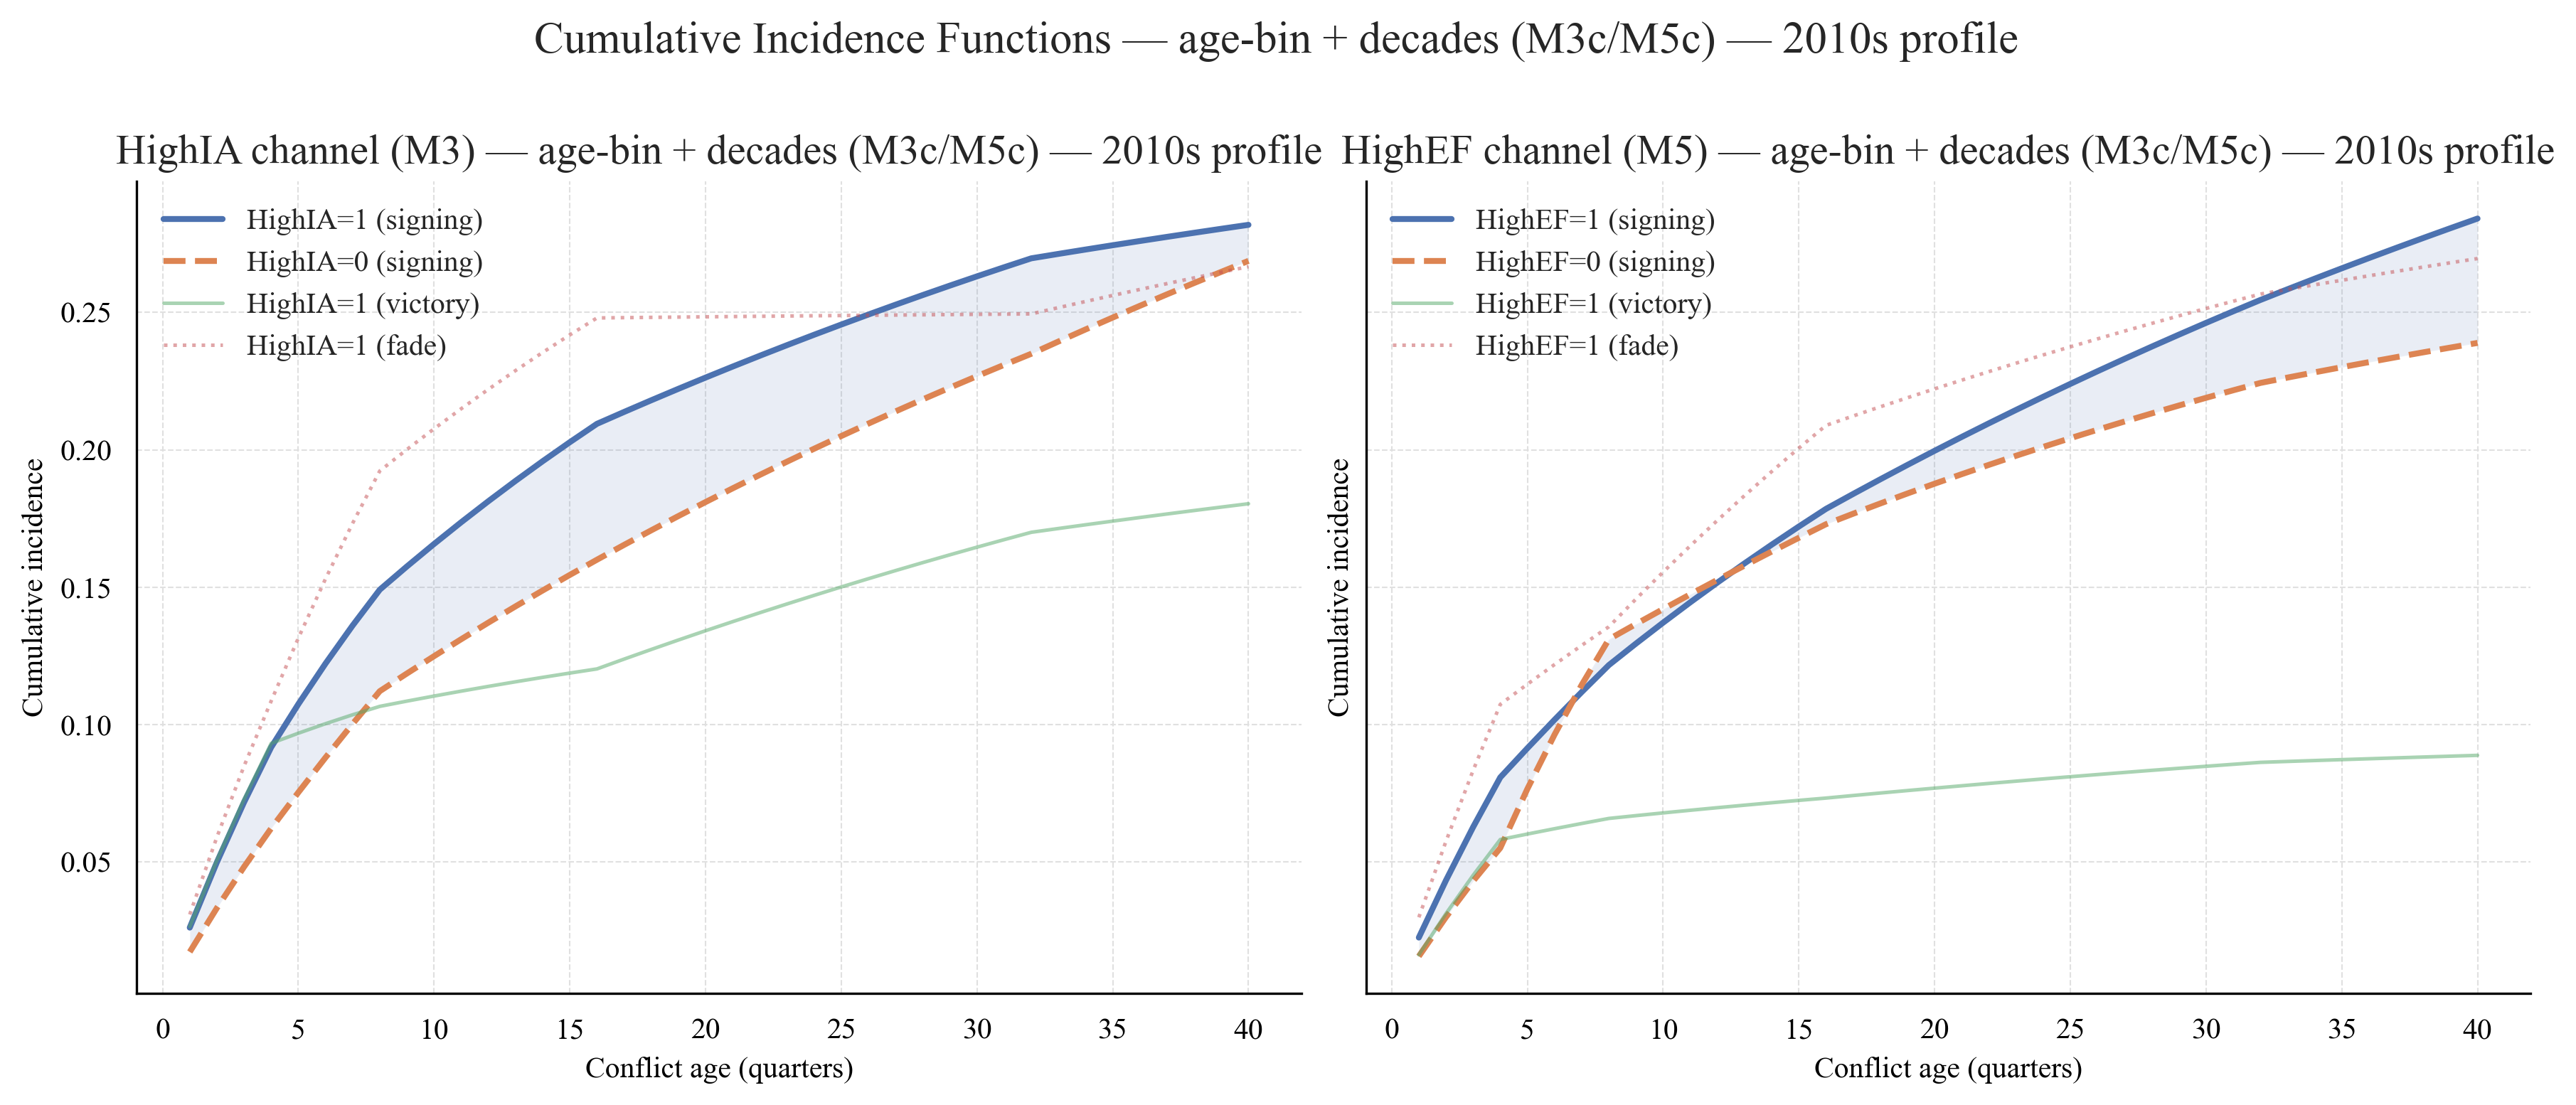

  Saved: results/cif_interaction_dec.png


In [18]:
# ── 3.  Compute and plot CIF — age-bin + decade controls (2010s profile) ──────

_dec = dict(d_2000s=1, d_2010s=1, d_2020s=0)

cif_ia1_dec = compute_cif(mn_ia_dec, M3_DEC, AGE_RANGE, high_ia_bin=1, **_dec)
cif_ia0_dec = compute_cif(mn_ia_dec, M3_DEC, AGE_RANGE, high_ia_bin=0, **_dec)
cif_ef1_dec = compute_cif(mn_ef_dec, M5_DEC, AGE_RANGE, high_fe_etfra_bin=1, **_dec)
cif_ef0_dec = compute_cif(mn_ef_dec, M5_DEC, AGE_RANGE, high_fe_etfra_bin=0, **_dec)

print("CIF_S at key horizons — HighIA channel (M3c, age-bin + dec, 2010s profile):")
_print_horizons(cif_ia1_dec, cif_ia0_dec, 'HighIA=1', 'HighIA=0', 'CIF_S')

print("CIF_S at key horizons — HighEF channel (M5c, age-bin + dec, 2010s profile):")
_print_horizons(cif_ef1_dec, cif_ef0_dec, 'HighEF=1', 'HighEF=0', 'CIF_S')

_plot_cif(cif_ia1_dec, cif_ia0_dec, cif_ef1_dec, cif_ef0_dec,
          title_suffix='age-bin + decades (M3c/M5c) — 2010s profile',
          save_path='results/cif_interaction_dec.png')
